In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

# **Data Loading**

In [6]:
from google.colab import files
uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [8]:
df = pd.read_csv("retail_sales_dataset.csv")

# **Data Cleaning**

In [9]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

df['Date'] = pd.to_datetime(df['Date'])

df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


# **Descriptive status**

In [13]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [14]:
df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].mean()

,0
Age,41.392
Quantity,2.514
Price per Unit,179.890
Total Amount,456.000


In [15]:
df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].median()

,0
Age,42.0
Quantity,3.0
Price per Unit,50.0
Total Amount,135.0


In [16]:
df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].mode()

,Age,Quantity,Price per Unit,Total Amount
0,43,4.0,50.0,50.0
1,64,NaN,NaN,NaN


In [17]:
df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].std()

,0
Age,13.681430
Quantity,1.132734
Price per Unit,189.681356
Total Amount,559.997632


# **Time Series ANalysis**

In [18]:
daily_sales = df.groupby('Date')['Total Amount'].sum()

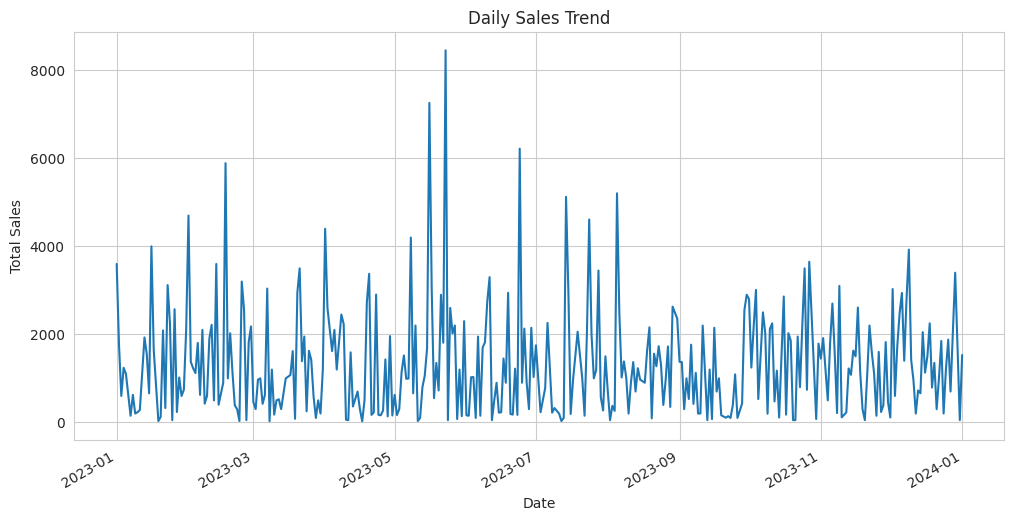

In [19]:
plt.figure(figsize=(12,6))
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

In [20]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()
monthly_sales = monthly_sales.astype(float)

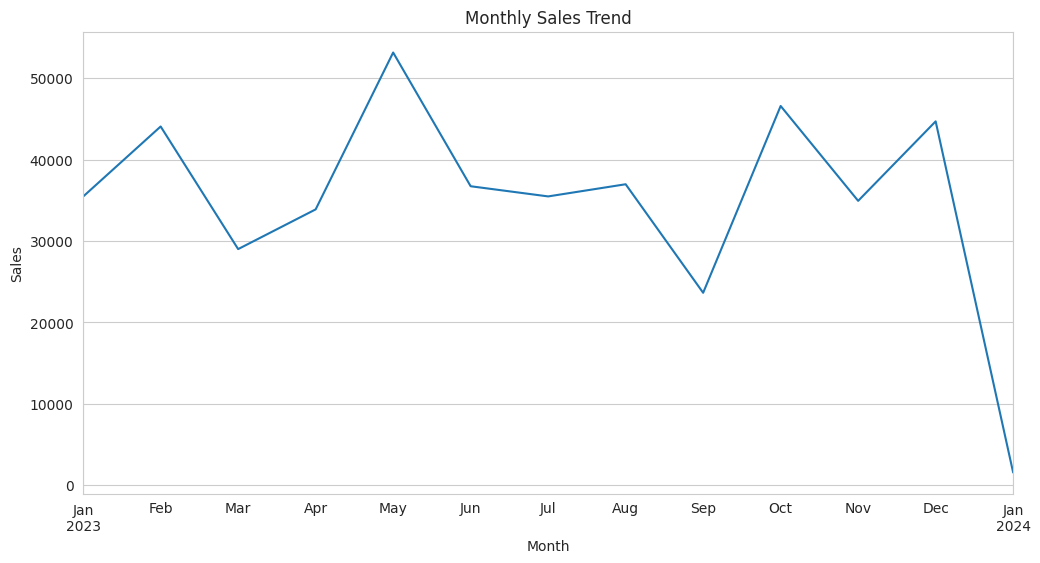

In [21]:
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# **Customer Analysis**

**Gender Spending**

In [22]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()
gender_sales

,Total Amount
Gender,
Female,232840
Male,223160


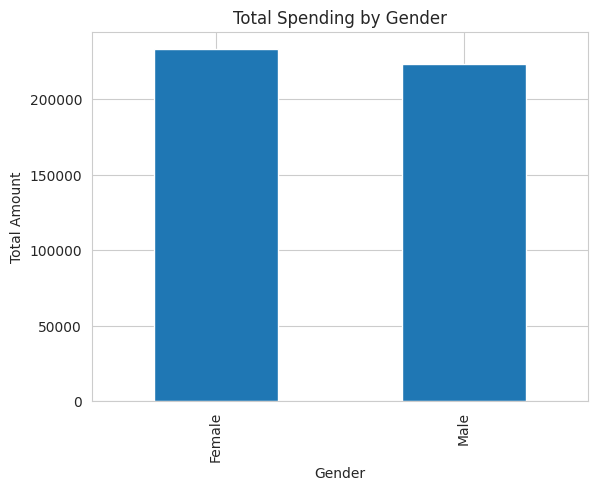

In [23]:
gender_sales.plot(kind='bar')
plt.title("Total Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Amount")
plt.show()

**Age group analysis**


In [24]:
bins = [18, 25, 35, 45, 60]
labels = ['18-25', '26-35', '36-45', '46-60']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [25]:
age_sales = df.groupby('Age Group')['Total Amount'].sum()
age_sales

,Total Amount
Age Group,
18-25,73335
26-35,98480
36-45,91870
46-60,147875


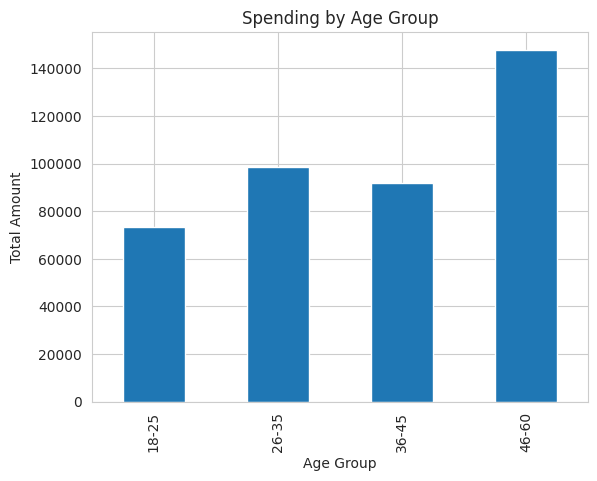

In [26]:
age_sales.plot(kind='bar')
plt.title("Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Amount")
plt.show()

In [27]:
top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)
top_customers

,Total Amount
Customer ID,
CUST015,2000
CUST412,2000
CUST970,2000
CUST547,2000
CUST281,2000
CUST416,2000
CUST420,2000
CUST927,2000
CUST447,2000


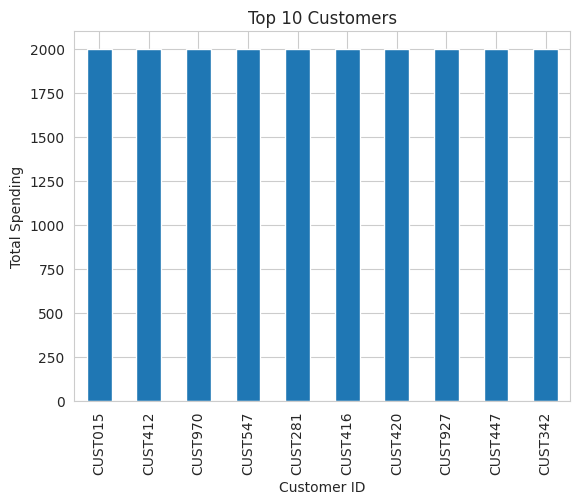

In [28]:
top_customers.plot(kind='bar')
plt.title("Top 10 Customers")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.show()

# **Product Category analysis**

In [29]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()
category_sales

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


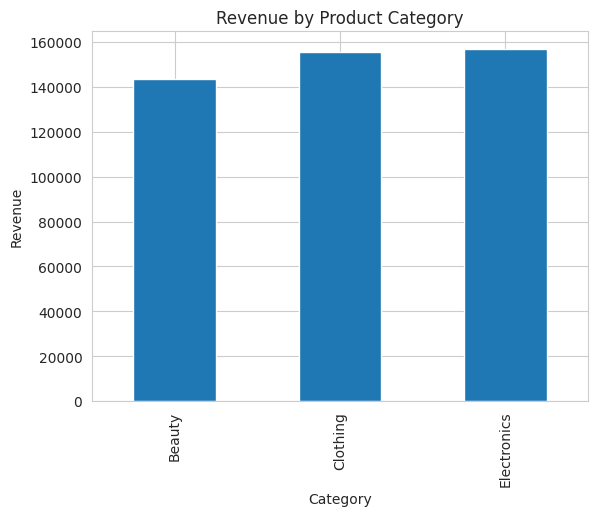

In [30]:
category_sales.plot(kind='bar')
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

In [31]:
category_quantity = df.groupby('Product Category')['Quantity'].sum()
category_quantity

,Quantity
Product Category,
Beauty,771
Clothing,894
Electronics,849


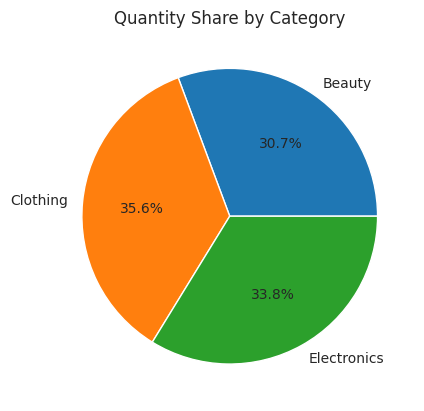

In [32]:
category_quantity.plot(kind='pie', autopct='%1.1f%%')
plt.title("Quantity Share by Category")
plt.ylabel("")
plt.show()

# **Quantity anlysis**

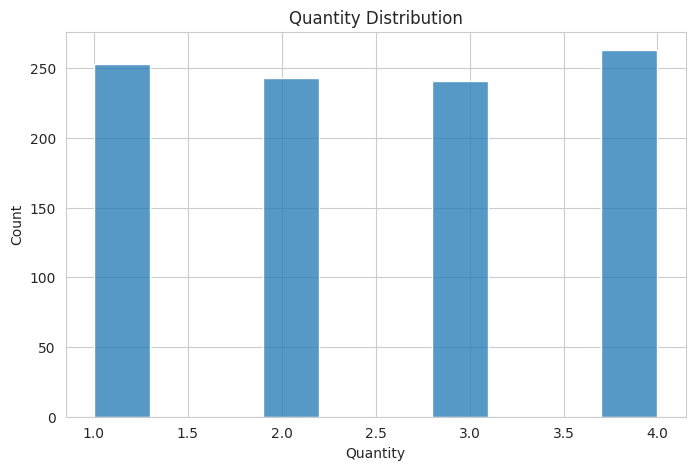

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df['Quantity'], bins=10)
plt.title("Quantity Distribution")
plt.show()

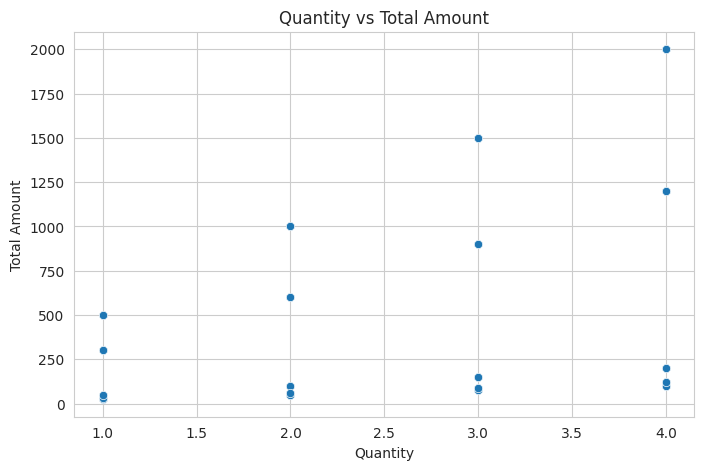

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Quantity', y='Total Amount', data=df)
plt.title("Quantity vs Total Amount")
plt.show()

# **Correlation Analysis**

In [35]:
corr = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

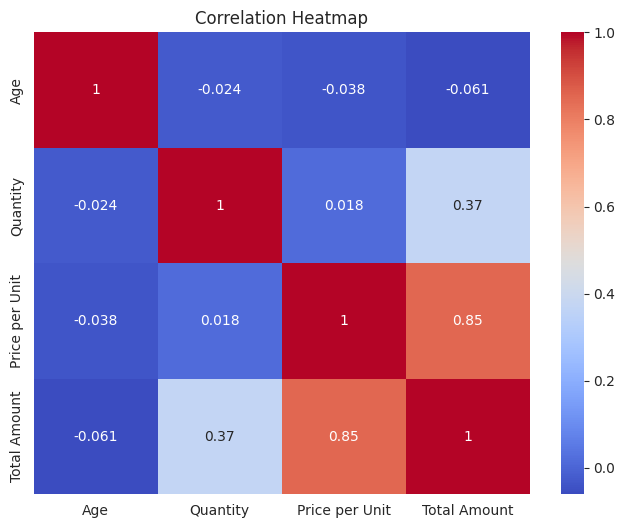

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The analysis indicates that product price is the strongest factor influencing total sales revenue, while customer age does not significantly affect purchasing behavior.

# **Outlier Detection**

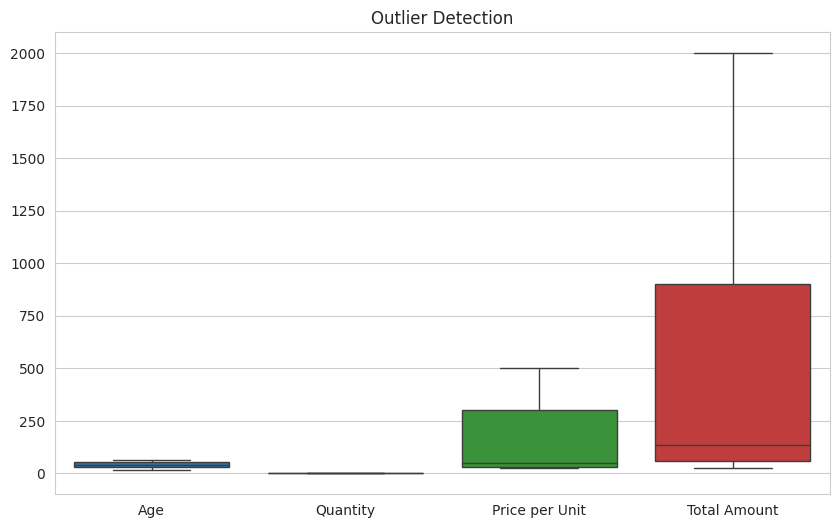

In [37]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']])
plt.title("Outlier Detection")
plt.show()

The presence of high values in Price per Unit and Total Amount likely reflects genuine purchasing behavior rather than data errors, especially in retail where expensive items or bulk purchases are common. Therefore, these values should be retained for analysis unless domain-specific rules suggest otherwise.